In [1]:
# !gdown 1jxSR9Cov4XaTXY1kPUnMFk7MaXR-bcQ5

In [2]:
FILE_PATH = 'dubai-transactions.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle
import numpy as np
pd.set_option('display.float_format', '{:,.5f}'.format)


In [4]:
def format_num(num):
  return "{:,}".format(num)

def df_status(df):
    print(f"{format_num(len(df))} Samples & {len(df.columns)} Features")

In [5]:
df = pd.read_csv(FILE_PATH)

In [6]:
df.columns
df.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2014-788,9,3,هبات,Gifts,هبه,Grant,06-11-2014,4,فيلا,...,NaN,0,"3,932.38000","24,789,724.00000","6,304.00000",NaN,NaN,2.00000,1.00000,0.00000
1,2-13-1999-1955,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,23-11-1999,4,فيلا,...,NaN,0,"1,393.55000","250,000.00000",179.40000,NaN,NaN,1.00000,1.00000,0.00000
2,2-13-2007-1862,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,26-09-2007,4,فيلا,...,NaN,0,"1,998.81000","300,000.00000",150.09000,NaN,NaN,1.00000,1.00000,0.00000
3,1-11-2003-975,11,1,مبايعات,Sales,بيع,Sell,02-07-2003,4,فيلا,...,NaN,0,257.43000,"470,000.00000","1,825.74000",NaN,NaN,1.00000,1.00000,0.00000
4,1-11-2016-170,11,1,مبايعات,Sales,بيع,Sell,05-01-2016,2,مبنى,...,NaN,0,818.38000,"13,000,000.00000","15,885.04000",NaN,NaN,14.00000,1.00000,0.00000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1475500 entries, 0 to 1475499
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1475500 non-null  str    
 1   procedure_id          1475500 non-null  int64  
 2   trans_group_id        1475500 non-null  int64  
 3   trans_group_ar        1475500 non-null  str    
 4   trans_group_en        1475500 non-null  str    
 5   procedure_name_ar     1475500 non-null  str    
 6   procedure_name_en     1475500 non-null  str    
 7   instance_date         1475500 non-null  str    
 8   property_type_id      1475500 non-null  int64  
 9   property_type_ar      1475500 non-null  str    
 10  property_type_en      1475500 non-null  str    
 11  property_sub_type_id  1163935 non-null  float64
 12  property_sub_type_ar  1163935 non-null  str    
 13  property_sub_type_en  1163935 non-null  str    
 14  property_usage_ar     1475500 non-null  str  

In [8]:
df['procedure_name_en'].unique()

<StringArray>
[                                           'Grant',
                            'Mortgage Registration',
                                             'Sell',
                                  'Modify Mortgage',
                              'Adding Land By Sell',
                  'Portfolio Mortgage Registration',
                        'Lease to Own Registration',
                       'Lease Finance Registration',
                                'Mortgage Transfer',
                         'Development Registration',
                                     'Delayed Sell',
                          'Sell - Pre registration',
                                'Grant Development',
                                 'Sell Development',
                             'Development Mortgage',
                        'Mortgage Pre-Registration',
                           'Grant Pre-Registration',
       'Lease to Own Registration Pre-Registration',
                            'Lea

# Data Pre-Processing


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1475500 entries, 0 to 1475499
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1475500 non-null  str    
 1   procedure_id          1475500 non-null  int64  
 2   trans_group_id        1475500 non-null  int64  
 3   trans_group_ar        1475500 non-null  str    
 4   trans_group_en        1475500 non-null  str    
 5   procedure_name_ar     1475500 non-null  str    
 6   procedure_name_en     1475500 non-null  str    
 7   instance_date         1475500 non-null  str    
 8   property_type_id      1475500 non-null  int64  
 9   property_type_ar      1475500 non-null  str    
 10  property_type_en      1475500 non-null  str    
 11  property_sub_type_id  1163935 non-null  float64
 12  property_sub_type_ar  1163935 non-null  str    
 13  property_sub_type_en  1163935 non-null  str    
 14  property_usage_ar     1475500 non-null  str  

## 14,75,500 samples & 46 features

In [10]:
df['parsed_date'] = pd.to_datetime(df['instance_date'], format='%d-%m-%Y')

In [11]:
df['property_sub_type_en'].unique()

<StringArray>
[                 nan,               'Flat',             'Office',
              'Villa',               'Shop',              'Store',
    'Hotel Apartment',        'Hotel Rooms',              'Hotel',
         'Show Rooms',           'Workshop',          'Warehouse',
    'Sized Partition',           'Building', 'Stacked Townhouses',
             'Clinic',          'Gymnasium',            'Parking',
               'Unit']
Length: 19, dtype: str

In [12]:
print("\n\nLast 10 Entries \n\n")
print(df.sort_values(by='parsed_date').tail(10))
print("\n\n-----------------")
print("\n\nFirst 10 Entries \n\n")
print(df.sort_values(by='parsed_date').head(10))



Last 10 Entries 


           transaction_id  procedure_id  trans_group_id trans_group_ar  \
709924    2-13-2025-16158            13               2           رهون   
953600    2-13-2025-16258            13               2           رهون   
836523    1-11-2025-24311            11               1        مبايعات   
1136817     3-9-2025-3437             9               3           هبات   
710559   1-102-2025-50100           102               1        مبايعات   
1279687   1-41-2025-18053            41               1        مبايعات   
1463181   2-13-2025-16277            13               2           رهون   
580229   1-102-2025-49945           102               1        مبايعات   
710849      2-39-2025-498            39               2           رهون   
1396089    1-133-2025-291           133               1        مبايعات   

        trans_group_en  procedure_name_ar         procedure_name_en  \
709924       Mortgages          تسجيل رهن     Mortgage Registration   
953600       Mortgages

In [13]:
# the first four transactions are from 1416 to 1422 which seems weird and can be removed. They will skew the data unnecessarily

### We have transaction data from 18th January, 1966 to 12th June, 2025

In [14]:
df[df['parsed_date'].isna()]

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date


In [15]:
df1 = df[4:].reset_index(drop=True)

In [16]:
print(f"Total transactions earlier: {len(df)}")
print(f"Total transactions now: {len(df1)}")

Total transactions earlier: 1475500
Total transactions now: 1475496


In [17]:
print(f"Earliest transaction earlier was {df.loc[0, 'parsed_date']}")
print(f"Earliest transaction now is {df1.loc[0, 'parsed_date']}")

Earliest transaction earlier was 2014-11-06 00:00:00
Earliest transaction now is 2016-01-05 00:00:00


## Now we are left with 14,75,496 transactions

In [18]:
df1.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
0,1-11-2016-170,11,1,مبايعات,Sales,بيع,Sell,05-01-2016,2,مبنى,...,0,818.38000,"13,000,000.00000","15,885.04000",NaN,NaN,14.00000,1.00000,0.00000,2016-01-05
1,1-11-2021-14213,11,1,مبايعات,Sales,بيع,Sell,20-08-2021,4,فيلا,...,0,306.58000,"1,908,000.00000","6,223.50000",NaN,NaN,11.00000,1.00000,0.00000,2021-08-20
2,1-11-2007-1737,11,1,مبايعات,Sales,بيع,Sell,19-06-2007,4,فيلا,...,0,334.45000,"2,800,000.00000","8,371.95000",NaN,NaN,1.00000,1.00000,0.00000,2007-06-19
3,1-11-2006-2352,11,1,مبايعات,Sales,بيع,Sell,18-12-2006,2,مبنى,...,0,785.03000,"720,325.00000",917.58000,NaN,NaN,1.00000,1.00000,0.00000,2006-12-18
4,1-11-2003-162,11,1,مبايعات,Sales,بيع,Sell,05-02-2003,2,مبنى,...,0,785.03000,"1,036,000.00000","1,319.69000",NaN,NaN,2.00000,1.00000,0.00000,2003-02-05


## Dropping Non-Informative Arabic Columns


In [19]:
ar_columns = [column for column in df1.columns.to_list() if column.endswith('_ar')]
ar_columns

['trans_group_ar',
 'procedure_name_ar',
 'property_type_ar',
 'property_sub_type_ar',
 'property_usage_ar',
 'reg_type_ar',
 'area_name_ar',
 'building_name_ar',
 'project_name_ar',
 'master_project_ar',
 'nearest_landmark_ar',
 'nearest_metro_ar',
 'nearest_mall_ar',
 'rooms_ar']

In [20]:
df2 = df1.drop(columns=ar_columns)

In [21]:
df2.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'instance_date', 'property_type_id',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_en',
       'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [22]:
df2.property_usage_en.unique()

<StringArray>
[             'Residential / Commercial',
                           'Residential',
                            'Commercial',
                                 'Other',
                            'Industrial',
               'Industrial / Commercial',
                             'Multi-Use',
                          'Agricultural',
                               'Storage',
                          'Hospitality ',
 'Industrial / Commercial / Residential']
Length: 11, dtype: str

## Filtering observations by Property Classifications

`property_usage_en` column

We need to make a decision to use which all properties from `property_usage_en`.
eg: If we want to just use Residential properties, then we need to filter out the usage types of following:
1. Residential
2. Residential / Commercial
3. Industrial / Commercial / Residential
4. Multi-Use

_Multi-Use might be removed seeing it's values_

In [23]:
allowed_usages = ['Residential', 'Residential / Commercial', 'Industrial / Commercial / Residential', 'Multi-Use']
res_df = df2[df2['property_usage_en'].isin(allowed_usages)]

In [24]:
res_df.info()

<class 'pandas.DataFrame'>
Index: 1261950 entries, 0 to 1475495
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1261950 non-null  str           
 1   procedure_id          1261950 non-null  int64         
 2   trans_group_id        1261950 non-null  int64         
 3   trans_group_en        1261950 non-null  str           
 4   procedure_name_en     1261950 non-null  str           
 5   instance_date         1261950 non-null  str           
 6   property_type_id      1261950 non-null  int64         
 7   property_type_en      1261950 non-null  str           
 8   property_sub_type_id  1041186 non-null  float64       
 9   property_sub_type_en  1041186 non-null  str           
 10  property_usage_en     1261950 non-null  str           
 11  reg_type_id           1261950 non-null  int64         
 12  reg_type_en           1261950 non-null  str           
 13

## 14,75,499 samples & 33 features

Property Type Evaluation

In [25]:
res_df.property_type_en.unique()

<StringArray>
['Building', 'Villa', 'Land', 'Unit']
Length: 4, dtype: str

We have 'Villa', 'Building', 'Land', 'Unit' types of properties

In [26]:
# For this model, let's focus on "Unit" type

res_units = res_df[res_df['property_type_en'] == 'Unit']
res_units2 = res_units.drop(columns=['property_type_en', 'property_type_id'])
res_units2.info()

<class 'pandas.DataFrame'>
Index: 912015 entries, 456 to 1475495
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        912015 non-null  str           
 1   procedure_id          912015 non-null  int64         
 2   trans_group_id        912015 non-null  int64         
 3   trans_group_en        912015 non-null  str           
 4   procedure_name_en     912015 non-null  str           
 5   instance_date         912015 non-null  str           
 6   property_sub_type_id  912015 non-null  float64       
 7   property_sub_type_en  912015 non-null  str           
 8   property_usage_en     912015 non-null  str           
 9   reg_type_id           912015 non-null  int64         
 10  reg_type_en           912015 non-null  str           
 11  area_id               912015 non-null  int64         
 12  area_name_en          912015 non-null  str           
 13  building_nam

## Property Subtype

In [27]:
res_units2.property_sub_type_en.unique()

<StringArray>
['Flat', 'Stacked Townhouses', 'Unit']
Length: 3, dtype: str

We have 3 types of sub types now:

1. Flat
2. Stacked Townhouses
3. Unit

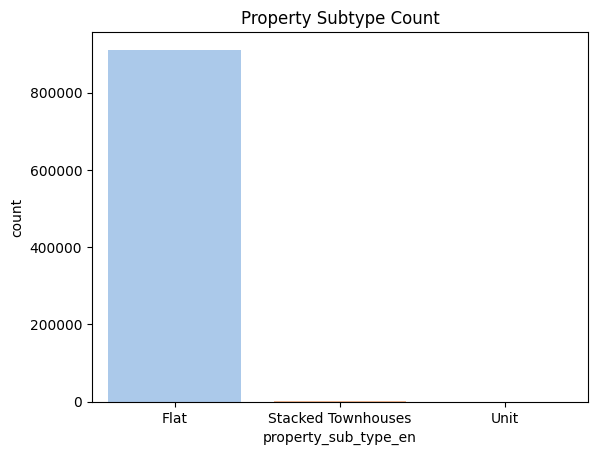

In [28]:
sns.countplot(data=res_units2, x='property_sub_type_en', legend='auto', stat='count', palette='pastel', hue='property_sub_type_en')
plt.title('Property Subtype Count')
plt.show()

In [29]:
res_units2.property_sub_type_en.value_counts()

property_sub_type_en
Flat                  911523
Stacked Townhouses       491
Unit                       1
Name: count, dtype: int64

Since we don't want Stacked Townhouses for now and the unit is only 1 in count. It's better to just filter out the flats.

In [30]:
flats_df = res_units2[res_units2['property_sub_type_en'] == 'Flat']
flats_df2 = flats_df.drop(columns=['property_sub_type_en', 'property_sub_type_id'])
flats_df2.info()

<class 'pandas.DataFrame'>
Index: 911523 entries, 456 to 1475495
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        911523 non-null  str           
 1   procedure_id          911523 non-null  int64         
 2   trans_group_id        911523 non-null  int64         
 3   trans_group_en        911523 non-null  str           
 4   procedure_name_en     911523 non-null  str           
 5   instance_date         911523 non-null  str           
 6   property_usage_en     911523 non-null  str           
 7   reg_type_id           911523 non-null  int64         
 8   reg_type_en           911523 non-null  str           
 9   area_id               911523 non-null  int64         
 10  area_name_en          911523 non-null  str           
 11  building_name_en      911523 non-null  str           
 12  project_number        701643 non-null  float64       
 13  project_name

## 9,11,523 Samples and 29 Features

We can remove _instance_date_, since we already have _parsed_date_

In [31]:
flats_df3 = flats_df2.drop(columns=['instance_date'])
flats_df3.shape

(911523, 28)

## 9,11,523 Samples and 28 Features

In [32]:
flats_df3.info()

<class 'pandas.DataFrame'>
Index: 911523 entries, 456 to 1475495
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        911523 non-null  str           
 1   procedure_id          911523 non-null  int64         
 2   trans_group_id        911523 non-null  int64         
 3   trans_group_en        911523 non-null  str           
 4   procedure_name_en     911523 non-null  str           
 5   property_usage_en     911523 non-null  str           
 6   reg_type_id           911523 non-null  int64         
 7   reg_type_en           911523 non-null  str           
 8   area_id               911523 non-null  int64         
 9   area_name_en          911523 non-null  str           
 10  building_name_en      911523 non-null  str           
 11  project_number        701643 non-null  float64       
 12  project_name_en       701643 non-null  str           
 13  master_proje

In [33]:
flats_df3.property_usage_en.value_counts()

property_usage_en
Residential    911523
Name: count, dtype: int64

## Property Usage

Only 1 value type now exists, we can remove it.

In [34]:
flats_df4 = flats_df3.drop(columns=['property_usage_en'])
flats_df4.shape

(911523, 27)

In [35]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 911523 entries, 456 to 1475495
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        911523 non-null  str           
 1   procedure_id          911523 non-null  int64         
 2   trans_group_id        911523 non-null  int64         
 3   trans_group_en        911523 non-null  str           
 4   procedure_name_en     911523 non-null  str           
 5   reg_type_id           911523 non-null  int64         
 6   reg_type_en           911523 non-null  str           
 7   area_id               911523 non-null  int64         
 8   area_name_en          911523 non-null  str           
 9   building_name_en      911523 non-null  str           
 10  project_number        701643 non-null  float64       
 11  project_name_en       701643 non-null  str           
 12  master_project_en     864104 non-null  str           
 13  nearest_land

## 9,11,523 Samples & 27 Features

## Registration type

## 12,61,949 samples & 33 features left

## Dropping Non-Informative Identifier Columns

In [36]:
flats_df4.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [37]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 911523 entries, 456 to 1475495
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        911523 non-null  str           
 1   procedure_id          911523 non-null  int64         
 2   trans_group_id        911523 non-null  int64         
 3   trans_group_en        911523 non-null  str           
 4   procedure_name_en     911523 non-null  str           
 5   reg_type_id           911523 non-null  int64         
 6   reg_type_en           911523 non-null  str           
 7   area_id               911523 non-null  int64         
 8   area_name_en          911523 non-null  str           
 9   building_name_en      911523 non-null  str           
 10  project_number        701643 non-null  float64       
 11  project_name_en       701643 non-null  str           
 12  master_project_en     864104 non-null  str           
 13  nearest_land

In [38]:
for column in flats_df4.columns.to_list():
    print(f"Unique value count for {column}: {res_df[column].nunique()}")

Unique value count for transaction_id: 1261950
Unique value count for procedure_id: 50
Unique value count for trans_group_id: 3
Unique value count for trans_group_en: 3
Unique value count for procedure_name_en: 50
Unique value count for reg_type_id: 2
Unique value count for reg_type_en: 2
Unique value count for area_id: 191
Unique value count for area_name_en: 191
Unique value count for building_name_en: 3938
Unique value count for project_number: 2481
Unique value count for project_name_en: 2479
Unique value count for master_project_en: 193
Unique value count for nearest_landmark_en: 14
Unique value count for nearest_metro_en: 56
Unique value count for nearest_mall_en: 5
Unique value count for rooms_en: 14
Unique value count for has_parking: 2
Unique value count for procedure_area: 75142
Unique value count for actual_worth: 274051
Unique value count for meter_sale_price: 733822
Unique value count for rent_value: 13906
Unique value count for meter_rent_price: 26948
Unique value count f

In [39]:
## Dropping transaction_id column
flats_df5 = flats_df4.drop(columns=['transaction_id'])

In [40]:
flats_df5.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
456,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-11
457,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,1.00000,2.00000,0.00000,2020-03-09
458,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-17
459,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,1.00000,1.00000,0.00000,2023-04-12
460,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,1.00000,1.00000,0.00000,2017-10-10


## Evaluating `procedure_id` and `procedure_name_en`

In [41]:
flats_df5.columns

Index(['procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en',
       'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en',
       'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [42]:
flats_df5.procedure_name_en.nunique()

38

In [43]:
flats_df5.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration                       372812
Sell                                          286038
Mortgage Registration                          89645
Delayed Sell                                   44974
Lease to Own Registration                      36600
Grant                                          24878
Development Registration                        7094
Sell Development                                6954
Delayed Mortgage                                6608
Lease to Own Registration Pre-Registration      6129
Lease Finance Registration                      4578
Modify Mortgage                                 4366
Mortgage Pre-Registration                       4351
Development Mortgage                            3263
Development Registration Pre-Registration       3118
Grant Pre-Registration                          1636
Sale On Payment Plan                            1459
Delayed Development                             1182
Mortgage Transfer           

In [44]:
len(flats_df5)

911523

## ❗ Need more information on transaction procedure

Need to know which all types of transactions to use based on `procedure_name_en`

In [45]:
# Sell - Pre registration                       372812
# Sell                                          286038
# Mortgage Registration                          89645
# Delayed Sell                                   44974
# Lease to Own Registration                      36600
# Grant                                          24878
# Development Registration                        7094
# Sell Development                                6954
# Delayed Mortgage                                6608
# Lease to Own Registration Pre-Registration      6129
# Lease Finance Registration

most_likely_needed_procedures = ['Sell - Pre registration', 'Sell', 'Mortgage Registration', 
                                 'Delayed Sell', 'Lease to Own Registration', 'Grant',
                                 'Development Registration', 'Sell Development',
                                 'Delayed Mortgage', 'Lease to Own Registration Pre-Registration',
                                 'Lease Finance Registration']



In [46]:
likely_needed_transactions = len(flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)])
total_transactions = len(flats_df5)

print(f"Likely needed transactions are {round(likely_needed_transactions/total_transactions * 100, 2)}% of total transactions")

Likely needed transactions are 97.23% of total transactions


In [47]:
flats_df6 = flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)]

In [48]:
flats_df6.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
456,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-11
457,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,1.00000,2.00000,0.00000,2020-03-09
458,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-17
459,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,1.00000,1.00000,0.00000,2023-04-12
460,11,1,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,...,1,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,1.00000,1.00000,0.00000,2017-10-10


## Transaction Group

This has 2 columns:
1. trans_group_id (Identifier)
2. trans_group_en (Value)

In [49]:
flats_df6.trans_group_en.unique()

<StringArray>
['Sales', 'Mortgages', 'Gifts']
Length: 3, dtype: str

In [50]:
flats_df6.trans_group_en.value_counts()

trans_group_en
Sales        739236
Mortgages    122196
Gifts         24878
Name: count, dtype: int64

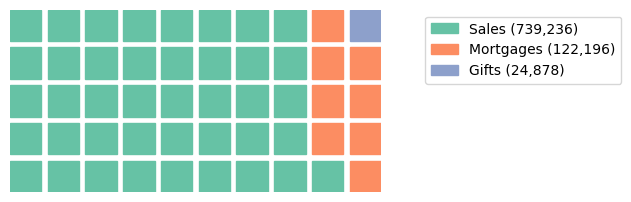

In [51]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values=flats_df5.trans_group_en.value_counts(),
    legend={
        'labels': [f"{k} ({format_num(v)})" for k, v in flats_df6.trans_group_en.value_counts().items()],
        'loc': 'upper left',
        'bbox_to_anchor': (1.1, 1)
    }
)
fig.savefig('transaction_group_composition.png')
plt.show()

In [52]:
flats_df6[flats_df6.trans_group_en == 'Gifts'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth
597,"9,523.80000",116.22000,"1,106,855.00000"
599,"8,656.16000",146.40000,"1,267,261.00000"
603,"9,387.27000",146.40000,"1,374,296.00000"
604,"8,658.81000",139.31000,"1,206,259.00000"
605,"9,521.52000",112.97000,"1,075,645.00000"


In [53]:
flats_df6[flats_df6.trans_group_en == 'Sales'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth
456,"16,096.00000",153.91000,"2,477,336.00000"
457,"9,797.52000",153.10000,"1,500,000.00000"
458,"8,670.23000",201.84000,"1,750,000.00000"
459,"10,156.56000",201.84000,"2,050,000.00000"
460,"14,876.27000",207.06000,"3,080,280.00000"


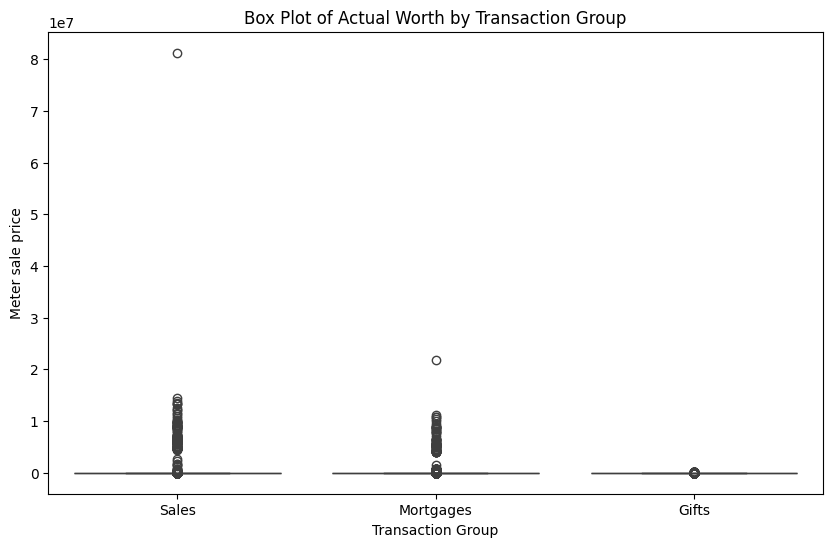

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=flats_df6, x='trans_group_en', y='meter_sale_price')
plt.title('Box Plot of Actual Worth by Transaction Group')
plt.xlabel('Transaction Group')
plt.ylabel('Meter sale price')
plt.show()

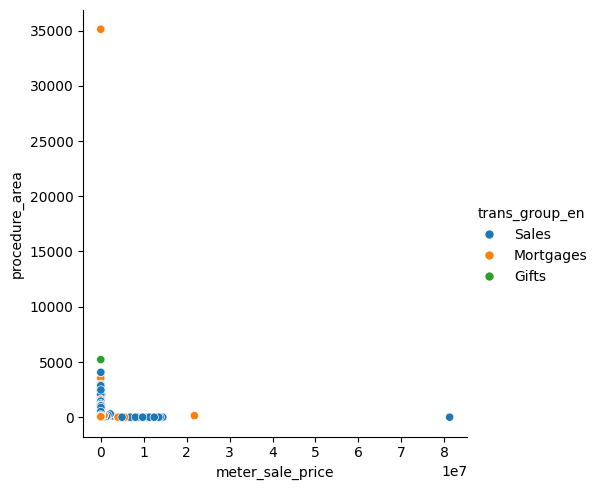

In [55]:
sns.relplot(data=flats_df6, x='meter_sale_price', y='procedure_area', hue='trans_group_en')

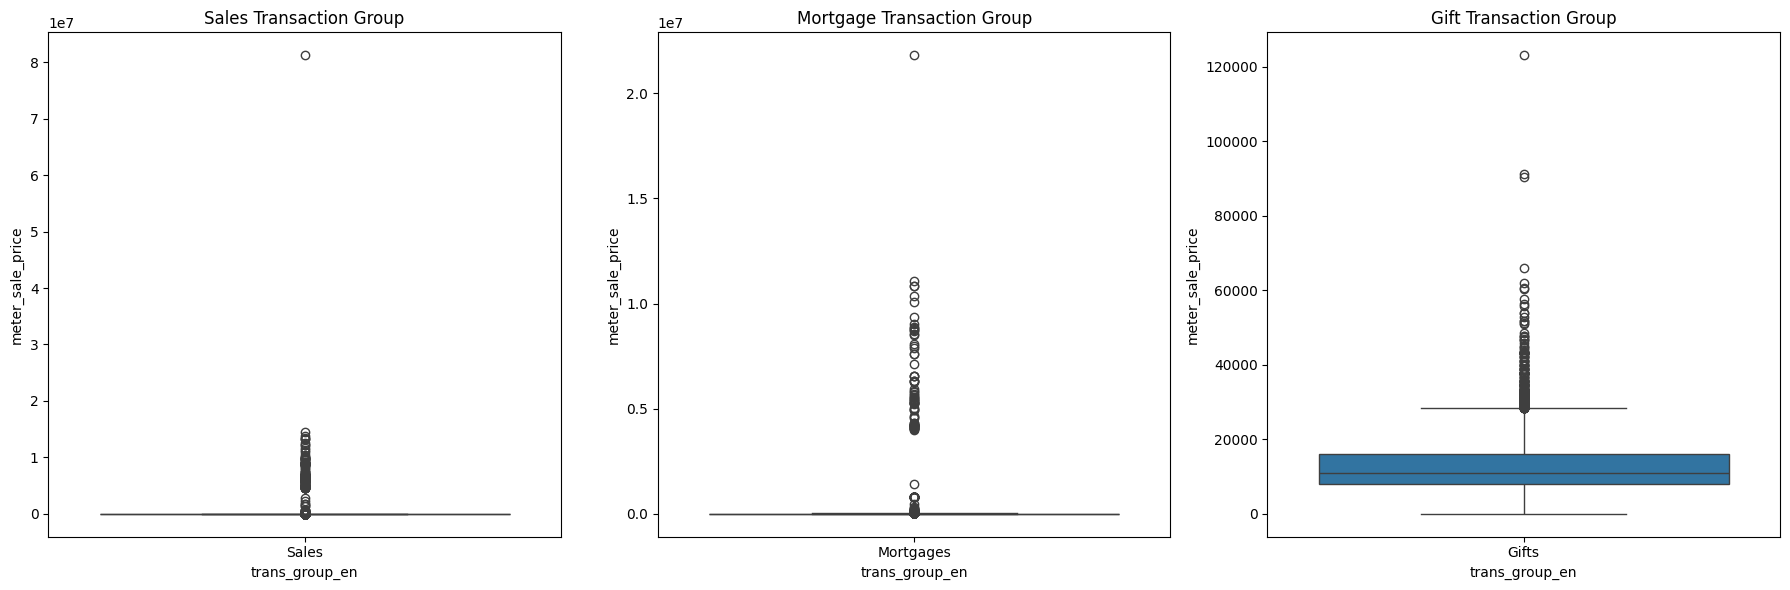

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sales_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Sales']
mortgage_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Mortgages']
gift_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Gifts']

sns.boxplot(
    data=sales_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[0]
)

sns.boxplot(
    data=mortgage_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[1]
)

sns.boxplot(
    data=gift_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[2]
)

axes[0].set_title('Sales Transaction Group')
axes[1].set_title('Mortgage Transaction Group')
axes[2].set_title('Gift Transaction Group')

plt.tight_layout()
plt.show()

In [57]:
sales_transaction_group['meter_sale_price'].describe()

count      739,236.00000
mean        16,825.82656
std        138,895.81643
min              0.01000
25%          9,259.75000
50%         13,545.56000
75%         19,572.08250
max     81,250,000.00000
Name: meter_sale_price, dtype: float64

In [58]:
mortgage_transaction_group['meter_sale_price'].describe()

count      122,196.00000
mean        13,982.29148
std        168,186.63587
min              5.62000
25%          6,458.32000
50%          8,738.66000
75%         12,148.00750
max     21,811,987.51000
Name: meter_sale_price, dtype: float64

In [59]:
gift_transaction_group['meter_sale_price'].describe()

count    24,878.00000
mean     12,714.77884
std       6,382.87109
min           1.50000
25%       7,985.28750
50%      10,854.22500
75%      16,145.85000
max     123,043.64000
Name: meter_sale_price, dtype: float64

The mean sale price for:
1. Sale properties is 16,825.9
2. Mortgage properties is 13,982
3. Gift properties is 12,714.8

In [60]:
12714/16825

0.7556612184249628

In [61]:
sale_mean_price = sales_transaction_group['meter_sale_price'].mean()
gift_mean_price = gift_transaction_group['meter_sale_price'].mean()
percent = round(gift_mean_price / sale_mean_price, 2) * 100

print(f"Gift sale price on average are {percent}% of sale mean price")

Gift sale price on average are 76.0% of sale mean price


In [62]:
print(f"Total sales transactions: {len(sales_transaction_group)}")
print(f"Total gift transactions: {len(gift_transaction_group)}")

print(f"Sales tr percentage: {round(len(sales_transaction_group)/len(flats_df6), 2) * 100}")
print(f"Gift tr percentage: {round(len(gift_transaction_group)/len(flats_df6), 2) * 100}")

Total sales transactions: 739236
Total gift transactions: 24878
Sales tr percentage: 83.0
Gift tr percentage: 3.0


In [63]:
# Since gift transactions are only 3 percent we, can remove them

/var/folders/j5/b_yzj8c173n5bygl1tcrnw840000gn/T/ipykernel_60878/1359685233.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


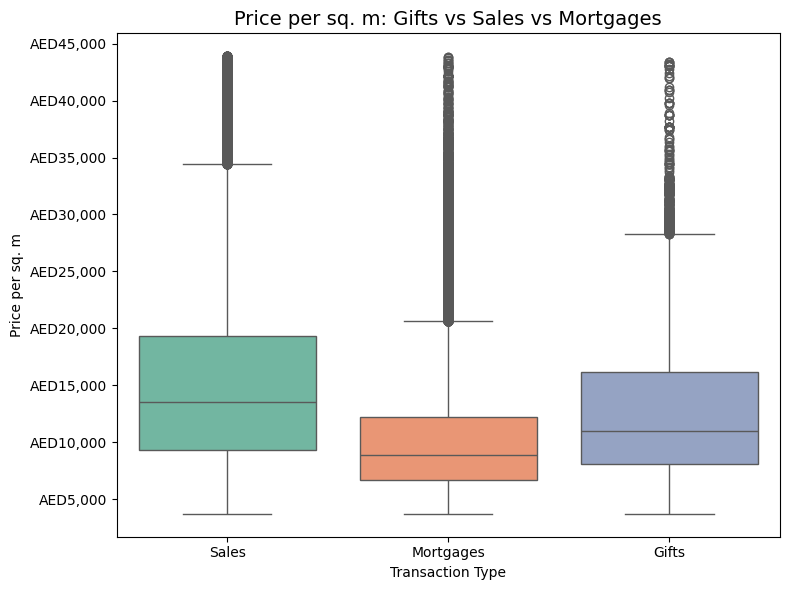

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

q_low = flats_df6['meter_sale_price'].quantile(0.01)
q_high = flats_df6['meter_sale_price'].quantile(0.99)
filtered_df = flats_df6[(flats_df6['meter_sale_price'] >= q_low) & (flats_df6['meter_sale_price'] <= q_high)]

plt.figure(figsize=(8,6))
sns.boxplot(
    x='trans_group_en',
    y='meter_sale_price',
    data=filtered_df,
    showfliers=True,
    palette="Set2"
)


import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('AED{x:,.0f}'))

plt.title("Price per sq. m: Gifts vs Sales vs Mortgages", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Price per sq. m")

plt.tight_layout()
plt.show()


In [65]:
flats_df7 = flats_df6[flats_df6['trans_group_en'] != 'Gifts']
print(f"With gift transactions, total = {len(flats_df6)}")
print(f"Without gift transactions, total = {len(flats_df7)}")

With gift transactions, total = 886310
Without gift transactions, total = 861432


In [66]:
flats_df7 = flats_df7.drop(columns=['trans_group_id'])

In [67]:
flats_df7.shape

(861432, 25)

In [68]:
print(f"{len(flats_df7)} Samples & {len(flats_df7.columns)} Features")

861432 Samples & 25 Features


In [69]:
flats_df7[['trans_group_en', 'procedure_name_en']].head(10)

,trans_group_en,procedure_name_en
456,Sales,Sell
457,Sales,Sell
458,Sales,Sell
459,Sales,Sell
460,Sales,Sell
461,Sales,Sell
488,Sales,Sell
489,Sales,Sell
490,Sales,Sell
491,Sales,Delayed Sell


In [70]:
flats_df7.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration                       372812
Sell                                          286038
Mortgage Registration                          89645
Delayed Sell                                   44974
Lease to Own Registration                      36600
Development Registration                        7094
Sell Development                                6954
Delayed Mortgage                                6608
Lease to Own Registration Pre-Registration      6129
Lease Finance Registration                      4578
Name: count, dtype: int64

In [71]:
flats_df7.head()

,procedure_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,project_name_en,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
456,11,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,NaN,...,1,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-11
457,11,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,NaN,...,1,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,1.00000,2.00000,0.00000,2020-03-09
458,11,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,NaN,...,1,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-17
459,11,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,NaN,...,1,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,1.00000,1.00000,0.00000,2023-04-12
460,11,Sales,Sell,1,Existing Properties,330,Marsa Dubai,Al Fattan Marine Towers,NaN,NaN,...,1,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,1.00000,1.00000,0.00000,2017-10-10


In [72]:
flats_df7.reg_type_en.value_counts()

reg_type_en
Existing Properties    482491
Off-Plan Properties    378941
Name: count, dtype: int64

In [73]:
# from sklearn.preprocessing import OneHotEncoder

In [74]:
# encoder = OneHotEncoder(sparse_output=False)
# encoded_reg_type = encoder.fit_transform(flats_df6[['reg_type_en']])

In [75]:
# print(encoded_reg_type)

In [76]:
# encoded_reg_type

In [77]:
# encoder.get_feature_names_out(['reg_type_en'])

In [78]:
# encoded_df = pd.DataFrame(encoded_reg_type, columns=encoder.get_feature_names_out(['reg_type_en']))
# encoded_df.head()

In [79]:
# flats_df7 = pd.concat([flats_df6.drop(columns=['reg_type_en', 'reg_type_id']), encoded_df], axis=1)

In [80]:
# flats_df7.head()
# len(flats_df7)

In [81]:
# area_names_df = flats_df7.area_name_en.value_counts().reset_index()
# area_names_df.shape

## Area name en and id

In [82]:
mapping_check = flats_df7.groupby('area_id')['area_name_en'].nunique()
type(mapping_check)

pandas.Series

In [83]:
print(f"No. of conflicts: {len(mapping_check[mapping_check > 1])}")

No. of conflicts: 0


In [84]:
flats_df8 = flats_df7.drop(columns=['area_id'])

In [85]:
flats_df8.shape
# flats_df8.head()

(861432, 24)

In [86]:
def _clean_name(name):
  if pd.isna(name):
    return 'Unknown'
  return name.strip()

In [87]:
flats_df9 = flats_df8.drop(columns=['area_name_en'])
flats_df9['area_name_en'] = flats_df8['area_name_en'].apply(_clean_name)

In [88]:
flats_df9['area_name_en'].value_counts()

area_name_en
Marsa Dubai                    114786
Al Barsha South Fourth          73541
Burj Khalifa                    63055
Business Bay                    53125
Al Thanyah Fifth                47313
                                ...  
Um Hurair Second                  165
Al Qusais Industrial Fourth       160
Nad Al Hamar                       67
Trade Center First                  4
Hessyan Second                      3
Name: count, Length: 69, dtype: int64

In [89]:
# area_name_en will use

`area_name_en` transformation will be done via OHE.

The project_number and project_name_en have a 1-1 mapping.

In [90]:
flats_df9 = flats_df9.drop(columns=['project_number'])

In [91]:
df_status(flats_df9)

861,432 Samples & 23 Features


In [92]:
flats_df9.columns

Index(['procedure_id', 'trans_group_en', 'procedure_name_en', 'reg_type_id',
       'reg_type_en', 'building_name_en', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'area_name_en'],
      dtype='str')

In [93]:
flats_df9['project_name_en'].value_counts()

project_name_en
REMRAAM                       10421
SKY COURTS                     9430
INTERNATIONAL CITY EMARATI     4546
LAKESIDE                       3981
SEVEN CITY JLT                 3431
                              ...  
THE K SUITES                      1
RUFI PRIME VIEW                   1
PIXEL TOWER                       1
THE H.Q                           1
BERLIN BUSINESS TOWER             1
Name: count, Length: 1783, dtype: int64

In [94]:
without_project_name = flats_df9['project_name_en'].isna().sum()

In [95]:
print(f"There are a total of {without_project_name} Transactions without project name")
print(f"This is about {round(without_project_name/len(flats_df9),2)*100}%")
print("This can't be dropped, we need to mark them as unknown")

There are a total of 193620 Transactions without project name
This is about 22.0%
This can't be dropped, we need to mark them as unknown


In [96]:
flats_df9.drop(columns=['procedure_id'], inplace=True, errors='ignore')

In [97]:
flats_df9.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'rooms_en', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'area_name_en'],
      dtype='str')

## Area Name

In [98]:
flats_df9.area_name_en.nunique()

69

In [99]:
print(f"Missing area names in data: {flats_df9.area_name_en.isna().sum()}")


Missing area names in data: 0


## Building Name

# Categorical Features


In [100]:
flats_df9.select_dtypes(include=['str']).columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'rooms_en', 'area_name_en'],
      dtype='str')

In [101]:
flats_df9.rooms_en.value_counts()

rooms_en
1 B/R          355455
2 B/R          241063
Studio         170356
3 B/R           79863
4 B/R           10431
PENTHOUSE        1572
5 B/R            1394
Single Room       737
6 B/R              97
Shop               39
7 B/R               7
Office              4
8 B/R               2
9 B/R               1
Name: count, dtype: int64

In [102]:
room_map = {
    '1 B/R': 1,
    '2 B/R': 2,
    '3 B/R': 3,
    '4 B/R': 4,
    '5 B/R': 5,
    '6 B/R': 6,
    '7 B/R': 7,
    '8 B/R': 8,
    '9 B/R': 9,
    'Studio': 1,
    'Penthouse': 5,
    'Single Room': 1,
    'Shop': -1,
    'Office': -1,
}
flats_df9['rooms_num'] = flats_df9.rooms_en.map(room_map)

In [103]:
flats_df9['rooms_num'].describe()
flats_df9.shape

(861432, 23)

In [104]:
flats_df9.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'rooms_en', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'area_name_en', 'rooms_num'],
      dtype='str')

In [105]:
flats_df10 = flats_df9.drop(columns=['rooms_en'])

In [106]:
flats_df10.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price',
       'rent_value', 'meter_rent_price', 'no_of_parties_role_1',
       'no_of_parties_role_2', 'no_of_parties_role_3', 'parsed_date',
       'area_name_en', 'rooms_num'],
      dtype='str')

In [107]:
(flats_df10.rooms_num == -1).sum()

np.int64(43)

In [108]:
flats_df10[flats_df10.rooms_num == -1].head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,...,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date,area_name_en,rooms_num
2507,Sales,Sell,1,Existing Properties,MARINA DIAMOND - B,NaN,Dubai Marina,Burj Al Arab,Dubai Marina,Marina Mall,...,"800,000.00000","11,374.95000",NaN,NaN,1.00000,2.00000,0.00000,2023-02-21,Marsa Dubai,-1.00000
47611,Sales,Sell,1,Existing Properties,ALNAKHEEL 1,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,...,"288,800.00000","4,570.34000",NaN,NaN,1.00000,1.00000,0.00000,2010-09-14,Al Thanyah Third,-1.00000
70311,Mortgages,Mortgage Registration,1,Existing Properties,ALNAKHEEL 3,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,...,"600,000.00000","3,898.38000",NaN,NaN,1.00000,1.00000,0.00000,2008-09-24,Al Thanyah Third,-1.00000
70345,Sales,Sell,1,Existing Properties,ALNAKHEEL 1,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,...,"1,910,000.00000","9,903.04000",NaN,NaN,1.00000,1.00000,0.00000,2010-12-13,Al Thanyah Third,-1.00000
115946,Sales,Sell,1,Existing Properties,ALNAKHEEL 1,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,...,"1,625,000.00000","12,077.29000",NaN,NaN,1.00000,2.00000,0.00000,2010-05-17,Al Thanyah Third,-1.00000


In [109]:
# Drop samples with rooms_num = -1
flats_df11 = flats_df10[flats_df10.rooms_num != -1]


In [110]:
df_status(flats_df10)
df_status(flats_df11)

861,432 Samples & 22 Features
861,389 Samples & 22 Features


In [111]:
building_counts = flats_df11.building_name_en.value_counts()
building_counts

building_name_en
Seven City JLT           3431
Burj Khalifa             2934
PRINCESS TOWER           2704
Marina Pinnacle          2550
ELITE RESIDENCE          2459
                         ... 
RUFI PRIME VIEW             1
Pixel Tower                 1
The H.Q                     1
C11                         1
BERLIN BUSINESS TOWER       1
Name: count, Length: 3860, dtype: int64

No. of unique buildings: 3860
<class 'pandas.Series'>
count   3,860.00000
mean      223.15777
std       265.59596
min         1.00000
25%        56.00000
50%       149.00000
75%       286.00000
max     3,431.00000
Name: count, dtype: float64


Text(0, 0.5, 'Frequency of transactions for those buildings')

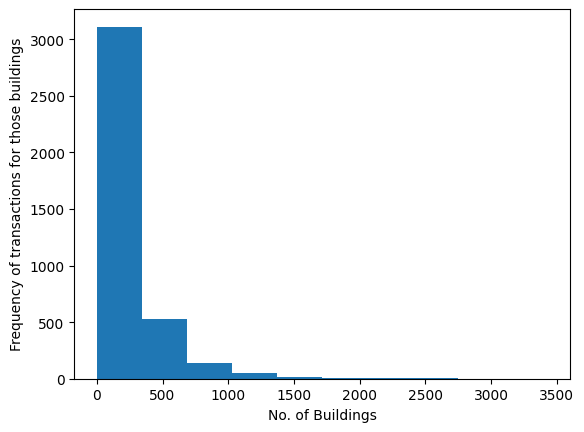

In [112]:
print(f"No. of unique buildings: {len(building_counts)}")
print(type(building_counts))
print(building_counts.describe())
plt.hist(building_counts)
plt.xlabel('No. of Buildings')
plt.ylabel('Frequency of transactions for those buildings')

In [113]:
mean_count = building_counts.mean()
print(f"Mean count: {round(mean_count, 2)}")

Mean count: 223.16


In [114]:
flats_df11.building_name_en.isna().sum()

np.int64(0)

In [115]:
no_trans_group_transactions = len(flats_df11[flats_df11.trans_group_en.isna()])
transactions_with_trans_group = len(flats_df11[~flats_df11.trans_group_en.isna()])
print(f"Rows with trans_group_en is null : {no_trans_group_transactions}")
print(f"Rows with trans_group_en is not null : {transactions_with_trans_group}")
print(f"Percentage of rows with trans_group_en is null : {round((no_trans_group_transactions / len(flats_df10)) * 100, 2)}%")

Rows with trans_group_en is null : 0
Rows with trans_group_en is not null : 861389
Percentage of rows with trans_group_en is null : 0.0%


In [116]:
df_status(flats_df11)

861,389 Samples & 22 Features


# One Hot Encoding Columns

1. trans_group_en
2. procedure_name_en
3. area_name_en
4. master_project_en
5. nearest_mall_en
6. nearest_metro_en
7. nearest_landmark_en

# Target Encoding Coumns

1. building_name_en
2. project_name_en

# Non Categorical Columns

In [117]:
non_categorical_columns = flats_df11.select_dtypes(exclude=['str']).columns

In [118]:
non_categorical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'rooms_num'],
      dtype='str')

In [119]:
flats_df11.reg_type_id.value_counts()

reg_type_id
1    482448
0    378941
Name: count, dtype: int64

In [120]:
flats_df11.reg_type_id.isna().sum()

np.int64(0)

In [121]:
flats_df11.reg_type_en.value_counts()

reg_type_en
Existing Properties    482448
Off-Plan Properties    378941
Name: count, dtype: int64

In [122]:
flats_df12 = flats_df11.drop(columns=['reg_type_en'])
## Since both reg_type_en and reg_type_id represent same thing,
## we drop reg_type_id
df_status(flats_df12)

861,389 Samples & 21 Features


In [123]:
flats_df12.has_parking.value_counts()

has_parking
1    798321
0     63068
Name: count, dtype: int64

In [124]:
flats_df12[['procedure_area', 'meter_sale_price', 'actual_worth']]

,procedure_area,meter_sale_price,actual_worth
456,153.91000,"16,096.00000","2,477,336.00000"
457,153.10000,"9,797.52000","1,500,000.00000"
458,201.84000,"8,670.23000","1,750,000.00000"
459,201.84000,"10,156.56000","2,050,000.00000"
460,207.06000,"14,876.27000","3,080,280.00000"
...,...,...,...
1475483,102.16000,"19,870.79000","2,030,000.00000"
1475486,40.49000,"12,864.57000","520,886.00000"
1475488,98.79000,"22,410.04000","2,213,888.00000"
1475491,67.73000,"5,076.67000","343,843.00000"


In [125]:
flats_df11.actual_worth.value_counts()
# actual_worth is the y
# meter_sale_price is correlated with actual_worth inversely; should be dropped
# flats_df12 = flats_df11.drop(columns=['meter_sale_price'])

actual_worth
1,000,000.00000     5253
500,000.00000       4571
1,200,000.00000     4505
600,000.00000       4346
800,000.00000       3892
                    ... 
2,326,894.00000        1
1,296,525.00000        1
21,191,277.00000       1
1,143,584.00000        1
343,843.00000          1
Name: count, Length: 198107, dtype: int64

In [126]:
flats_df11.shape

(861389, 22)

### Dropping meter_rent_price
Taking assumption that won't be available in final testing, so dropping the feature

DROPPING LATER. BECAUSE OF SOME DEBUGGING

In [127]:
# flats_df12 = flats_df11.drop(columns=['meter_rent_price', 'rent_value'])
flats_df12 = flats_df11

In [128]:
flats_df12.head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,...,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date,area_name_en,rooms_num
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,"2,477,336.00000","16,096.00000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-11,Marsa Dubai,2.00000
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,"1,500,000.00000","9,797.52000",NaN,NaN,1.00000,2.00000,0.00000,2020-03-09,Marsa Dubai,2.00000
458,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,"1,750,000.00000","8,670.23000",NaN,NaN,1.00000,1.00000,0.00000,2020-03-17,Marsa Dubai,3.00000
459,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,"2,050,000.00000","10,156.56000",NaN,NaN,1.00000,1.00000,0.00000,2023-04-12,Marsa Dubai,3.00000
460,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,"3,080,280.00000","14,876.27000",NaN,NaN,1.00000,1.00000,0.00000,2017-10-10,Marsa Dubai,3.00000


## Drop number of parties for registration



In [129]:
flats_df13 = flats_df12.drop(columns=['no_of_parties_role_1','no_of_parties_role_2', 'no_of_parties_role_3'])
df_status(flats_df13)

861,389 Samples & 19 Features


# Final Number of Features before any encoding is 15 including target variable

In [130]:
flats_df13.head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,2020-03-11,Marsa Dubai,2.00000
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,2020-03-09,Marsa Dubai,2.00000
458,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,2020-03-17,Marsa Dubai,3.00000
459,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,2023-04-12,Marsa Dubai,3.00000
460,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,2017-10-10,Marsa Dubai,3.00000


# Check Target Variable

In [131]:
flats_df13.actual_worth.describe()

count         861,389.00000
mean        1,552,968.29617
std         4,331,954.23604
min                 1.00000
25%           623,189.00000
50%         1,046,888.00000
75%         1,784,160.00000
max     3,013,326,074.00000
Name: actual_worth, dtype: float64

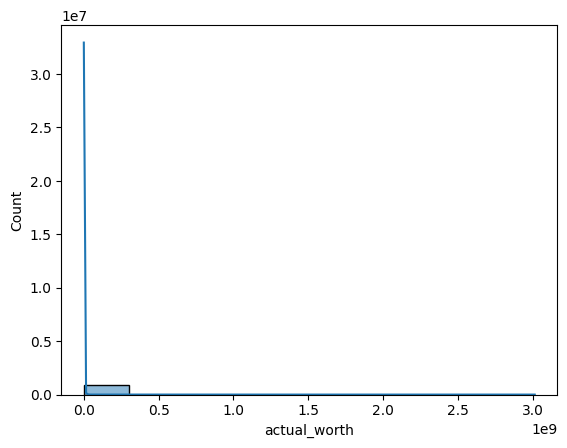

In [132]:
sns.histplot(flats_df13['actual_worth'], bins=10, kde=True)
plt.show()

In [133]:
skewness = flats_df13['actual_worth'].skew()
print(f"Skewness: {skewness:.2f}")


Skewness: 404.07


In [134]:
low_priced_transactions = flats_df13[flats_df13['actual_worth'] < 300000][['actual_worth', 'meter_sale_price', 'parsed_date']].sort_values(by='parsed_date')

In [135]:
print(f"Total transactions lower than 300k: {len(low_priced_transactions)}")

Total transactions lower than 300k: 31683


In [136]:
MAX_ACTUAL_WORTH = flats_df13.actual_worth.quantile(0.99)
high_priced_transactions =  flats_df13[flats_df13['actual_worth']>MAX_ACTUAL_WORTH]

In [137]:
print(f"Total transactions greater than 99 quantile: {len(high_priced_transactions)}")

Total transactions greater than 99 quantile: 8614


In [138]:
# Remove low priced transactions
flats_df14 = flats_df13[flats_df13['actual_worth'] > 300000]

In [139]:
df_status(flats_df13)
df_status(flats_df14)

861,389 Samples & 19 Features
826,958 Samples & 19 Features


In [140]:
flats_df15 = flats_df14[flats_df14['actual_worth'] < MAX_ACTUAL_WORTH]

In [141]:
df_status(flats_df14)
df_status(flats_df15)

826,958 Samples & 19 Features
818,344 Samples & 19 Features


In [142]:
flats_df15['actual_worth_log'] = np.log1p(flats_df15['actual_worth'])
flats_df15.head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,2020-03-11,Marsa Dubai,2.00000,14.72269
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,2020-03-09,Marsa Dubai,2.00000,14.22098
458,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,2020-03-17,Marsa Dubai,3.00000,14.37513
459,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,2023-04-12,Marsa Dubai,3.00000,14.53335
460,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,2017-10-10,Marsa Dubai,3.00000,14.94053


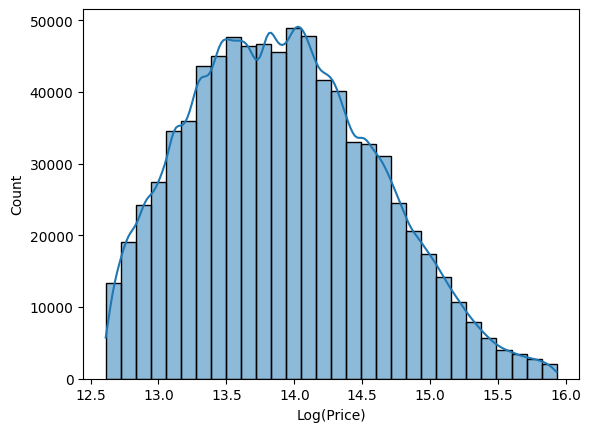

In [143]:
sns.histplot(flats_df15['actual_worth_log'], bins=30, kde=True)
plt.xlabel("Log(Price)")
plt.show()

In [144]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

In [145]:
# flats_df14['actual_worth_scaled'] = scaler.fit_transform(
#     flats_df14[['actual_worth_log']]
# )
# flats_df14.head()

In [146]:
# flats_df14.actual_worth_scaled.describe()

In [147]:
# import joblib

# joblib.dump(scaler, 'actual_worth_log_scaler.pkl')

In [148]:
# import joblib

# # Load the scaler
# scaler = joblib.load('scaler.pkl')

# # Inverse transform
# original_log_values = scaler.inverse_transform(flats_df14[['actual_worth_scaled']])
# original_values = np.expm1(original_log_values)


In [149]:
flats_df15['actual_worth_non_log'] = np.expm1(flats_df15['actual_worth_log'])
flats_df15.head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,...,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log,actual_worth_non_log
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,153.91000,"2,477,336.00000","16,096.00000",NaN,NaN,2020-03-11,Marsa Dubai,2.00000,14.72269,"2,477,336.00000"
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,153.10000,"1,500,000.00000","9,797.52000",NaN,NaN,2020-03-09,Marsa Dubai,2.00000,14.22098,"1,500,000.00000"
458,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,201.84000,"1,750,000.00000","8,670.23000",NaN,NaN,2020-03-17,Marsa Dubai,3.00000,14.37513,"1,750,000.00000"
459,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,201.84000,"2,050,000.00000","10,156.56000",NaN,NaN,2023-04-12,Marsa Dubai,3.00000,14.53335,"2,050,000.00000"
460,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,...,207.06000,"3,080,280.00000","14,876.27000",NaN,NaN,2017-10-10,Marsa Dubai,3.00000,14.94053,"3,080,280.00000"


In [150]:
flats_df16 = flats_df15.drop(columns=['actual_worth', 'actual_worth_non_log'])

In [151]:
flats_df16.head()


,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.91000,"16,096.00000",NaN,NaN,2020-03-11,Marsa Dubai,2.00000,14.72269
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.10000,"9,797.52000",NaN,NaN,2020-03-09,Marsa Dubai,2.00000,14.22098
458,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"8,670.23000",NaN,NaN,2020-03-17,Marsa Dubai,3.00000,14.37513
459,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,201.84000,"10,156.56000",NaN,NaN,2023-04-12,Marsa Dubai,3.00000,14.53335
460,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,NaN,NaN,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,207.06000,"14,876.27000",NaN,NaN,2017-10-10,Marsa Dubai,3.00000,14.94053


# Feature Columns

## Handling Null Values

In [152]:
flats_df16.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'has_parking', 'procedure_area', 'meter_sale_price', 'rent_value',
       'meter_rent_price', 'parsed_date', 'area_name_en', 'rooms_num',
       'actual_worth_log'],
      dtype='str')

In [153]:
flats_df16.isnull().mean() * 100

trans_group_en         0.00000
procedure_name_en      0.00000
reg_type_id            0.00000
reg_type_en            0.00000
building_name_en       0.00000
project_name_en       21.22689
master_project_en      5.40176
nearest_landmark_en   12.79132
nearest_metro_en      20.39142
nearest_mall_en       20.72869
has_parking            0.00000
procedure_area         0.00000
meter_sale_price       0.00000
rent_value            97.56264
meter_rent_price      97.56264
parsed_date            0.00000
area_name_en           0.00000
rooms_num              0.22313
actual_worth_log       0.00000
dtype: float64

In [154]:
flats_df16.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'has_parking', 'procedure_area', 'meter_sale_price', 'rent_value',
       'meter_rent_price', 'parsed_date', 'area_name_en', 'rooms_num',
       'actual_worth_log'],
      dtype='str')

In [155]:
flats_df16[flats_df16.master_project_en == 'Dubai Marina'].head(20)

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
590,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,59.16000,"10,141.99000",NaN,NaN,2011-01-24,Marsa Dubai,1.00000,13.30469
591,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,74.16000,"10,787.49000",NaN,NaN,2023-08-09,Marsa Dubai,1.00000,13.59237
592,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,74.16000,"8,198.49000",NaN,NaN,2010-08-03,Marsa Dubai,1.00000,13.31793
593,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,64.52000,"12,709.24000",NaN,NaN,2017-06-12,Marsa Dubai,1.00000,13.61706
594,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,73.33000,"11,182.33000",NaN,NaN,2013-10-03,Marsa Dubai,1.00000,13.61706
595,Mortgages,Mortgage Registration,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,71.91000,"6,605.48000",NaN,NaN,2014-07-14,Marsa Dubai,1.00000,13.07107
596,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,63.06000,"4,836.66000",NaN,NaN,2010-10-20,Marsa Dubai,1.00000,12.62807
598,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,71.91000,"12,724.24000",NaN,NaN,2014-02-11,Marsa Dubai,1.00000,13.72668
600,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,63.07000,"13,080.70000",NaN,NaN,2023-11-17,Marsa Dubai,1.00000,13.62314
601,Sales,Sell,1,Existing Properties,DREAM TOWER,NaN,Dubai Marina,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,64.52000,"7,532.55000",NaN,NaN,2010-10-27,Marsa Dubai,1.00000,13.09397


In [156]:
flats_df16.project_name_en.value_counts()

project_name_en
REMRAAM                                  10081
SKY COURTS                                8240
INTERNATIONAL CITY EMARATI                3837
SEVEN CITY JLT                            3426
LAKESIDE                                  3305
                                         ...  
RUFI PRIME VIEW                              1
PIXEL TOWER                                  1
THE H.Q                                      1
BERLIN BUSINESS TOWER                        1
Six Senses Residences The Palm, Dubai        1
Name: count, Length: 1748, dtype: int64

In [157]:
flats_df16[flats_df16.project_name_en == 'SKY COURTS'].head(50)

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
16044,Mortgages,Mortgage Registration,1,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,119.53000,"5,688.95000",NaN,NaN,2024-09-30,Wadi Al Safa 5,2.00000,13.42985
16045,Sales,Sell,1,Existing Properties,Skycourts Tower B,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,119.53000,"5,437.97000",NaN,NaN,2022-11-24,Wadi Al Safa 5,2.00000,13.38473
16046,Sales,Sell,1,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,39.75000,"9,256.41000",NaN,NaN,2015-09-10,Wadi Al Safa 5,1.00000,12.81568
16047,Sales,Sell - Pre registration,0,Off-Plan Properties,Skycourts Tower B,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,77.79000,"7,693.70000",NaN,NaN,2009-07-29,Wadi Al Safa 5,1.00000,13.30217
16049,Sales,Lease to Own Registration Pre-Registration,0,Off-Plan Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,40.70000,"7,720.12000",NaN,NaN,2009-10-26,Wadi Al Safa 5,1.00000,12.65781
16050,Sales,Sell,1,Existing Properties,Skycourts Tower A,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,88.58000,"5,588.17000",NaN,NaN,2024-09-18,Wadi Al Safa 5,1.00000,13.11232
16051,Sales,Lease to Own Registration,1,Existing Properties,Skycourts Tower D,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,78.29000,"7,424.58000",NaN,NaN,2013-01-29,Wadi Al Safa 5,1.00000,13.27297
16052,Sales,Lease to Own Registration,1,Existing Properties,Skycourts Tower A,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,79.17000,"6,804.99000",NaN,NaN,2011-10-12,Wadi Al Safa 5,1.00000,13.19701
16053,Sales,Sell,1,Existing Properties,Skycourts Tower F,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,101.18000,"7,906.70000",NaN,NaN,2025-06-03,Wadi Al Safa 5,2.00000,13.59237
16054,Sales,Sell - Pre registration,0,Off-Plan Properties,Skycourts Tower F,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,NaN,NaN,1,40.70000,"7,720.12000",NaN,NaN,2009-09-14,Wadi Al Safa 5,1.00000,12.65781


In [158]:
flats_df16[['building_name_en', 'project_name_en', 'master_project_en']]

,building_name_en,project_name_en,master_project_en
456,Al Fattan Marine Towers,NaN,NaN
457,Al Fattan Marine Towers,NaN,NaN
458,Al Fattan Marine Towers,NaN,NaN
459,Al Fattan Marine Towers,NaN,NaN
460,Al Fattan Marine Towers,NaN,NaN
...,...,...,...
1475483,Palace Residences,Palace Residences - Dubai Creek Harbour,The Lagoons
1475486,TRIA BY DEYAAR,TRIA BY DEYAAR,Silicon Oasis
1475488,Parkside Views,Parkside Views,DUBAI HILLS
1475491,EUROPEAN,CANAL RESIDENCE WEST (PHASE 1),Dubai Sports City


In [159]:
# Handle missing  project name

flats_df16[flats_df16.master_project_en.isna() & flats_df16.project_name_en.isna()]
flats_df17 = flats_df16.copy()
flats_df17['project_name_en'] = flats_df16['project_name_en'].fillna(flats_df16['building_name_en'])

In [160]:
flats_df17.project_name_en.isna().sum()

np.int64(0)

In [161]:
flats_df18 = flats_df17.copy()
flats_df18['master_project_en'] = flats_df17['master_project_en'].fillna(flats_df17['project_name_en'])

In [162]:
flats_df18.isna().sum()

trans_group_en              0
procedure_name_en           0
reg_type_id                 0
reg_type_en                 0
building_name_en            0
project_name_en             0
master_project_en           0
nearest_landmark_en    104677
nearest_metro_en       166872
nearest_mall_en        169632
has_parking                 0
procedure_area              0
meter_sale_price            0
rent_value             798398
meter_rent_price       798398
parsed_date                 0
area_name_en                0
rooms_num                1826
actual_worth_log            0
dtype: int64

In [163]:
flats_df18.nearest_landmark_en.value_counts()

nearest_landmark_en
Sports City Swimming Academy         184462
Burj Al Arab                         172384
Downtown Dubai                       122474
Motor City                            67112
IMG World Adventures                  50085
Burj Khalifa                          49770
Dubai International Airport           32296
Expo 2020 Site                        18924
Dubai Cycling Course                  10160
Al Makhtoum International Airport      3004
Global Village                         2077
Dubai Parks and Resorts                 917
Jabel Ali                                 2
Name: count, dtype: int64

In [164]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')

In [165]:
flats_df18.isna().mean() * 100

trans_group_en         0.00000
procedure_name_en      0.00000
reg_type_id            0.00000
reg_type_en            0.00000
building_name_en       0.00000
project_name_en        0.00000
master_project_en      0.00000
nearest_landmark_en    0.00000
nearest_metro_en      20.39142
nearest_mall_en       20.72869
has_parking            0.00000
procedure_area         0.00000
meter_sale_price       0.00000
rent_value            97.56264
meter_rent_price      97.56264
parsed_date            0.00000
area_name_en           0.00000
rooms_num              0.22313
actual_worth_log       0.00000
dtype: float64

In [166]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')
flats_df18['nearest_metro_en'] = flats_df18.nearest_metro_en.fillna('__MISSING__')
flats_df18['nearest_mall_en'] = flats_df18.nearest_mall_en.fillna('__MISSING__')


In [167]:
flats_df18.isna().mean() * 100

trans_group_en         0.00000
procedure_name_en      0.00000
reg_type_id            0.00000
reg_type_en            0.00000
building_name_en       0.00000
project_name_en        0.00000
master_project_en      0.00000
nearest_landmark_en    0.00000
nearest_metro_en       0.00000
nearest_mall_en        0.00000
has_parking            0.00000
procedure_area         0.00000
meter_sale_price       0.00000
rent_value            97.56264
meter_rent_price      97.56264
parsed_date            0.00000
area_name_en           0.00000
rooms_num              0.22313
actual_worth_log       0.00000
dtype: float64

In [168]:
flats_df19 = flats_df18.drop(columns=['rent_value', 'meter_rent_price'])
flats_df19.isna().mean() * 100

trans_group_en        0.00000
procedure_name_en     0.00000
reg_type_id           0.00000
reg_type_en           0.00000
building_name_en      0.00000
project_name_en       0.00000
master_project_en     0.00000
nearest_landmark_en   0.00000
nearest_metro_en      0.00000
nearest_mall_en       0.00000
has_parking           0.00000
procedure_area        0.00000
meter_sale_price      0.00000
parsed_date           0.00000
area_name_en          0.00000
rooms_num             0.22313
actual_worth_log      0.00000
dtype: float64

In [169]:
flats_df20 = flats_df19[~flats_df19['rooms_num'].isna()]
df_status(flats_df19)
df_status(flats_df20)

818,344 Samples & 17 Features
816,518 Samples & 17 Features


In [170]:
flats_df20[flats_df20.rooms_num.isna()].head(10)

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log


## Normalization for features

In [171]:
numerical_columns = flats_df20.select_dtypes(exclude=['str']).columns
numerical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'meter_sale_price',
       'parsed_date', 'rooms_num', 'actual_worth_log'],
      dtype='str')

In [172]:
# reg_type_id and has_parking are fine.

In [173]:
flats_df20.procedure_area.value_counts()

procedure_area
45.00000     3799
68.00000     3127
67.00000     2639
90.00000     2113
69.00000     2102
             ... 
575.79000       1
319.32000       1
257.87000       1
311.38000       1
203.95000       1
Name: count, Length: 23456, dtype: int64

In [174]:
flats_df20.procedure_area.skew()

np.float64(150.3233296400786)

In [175]:
flats_df20.procedure_area.describe()

count   816,518.00000
mean         99.05398
std          70.78404
min           0.01000
25%          63.22000
50%          83.88000
75%         123.61000
max      35,117.33000
Name: procedure_area, dtype: float64

In [176]:
flats_df20.procedure_area.quantile(0.8)
flats_df21 = flats_df20[(flats_df20.procedure_area < flats_df20.procedure_area.quantile(0.99)) &
                        (flats_df20.procedure_area > flats_df20.procedure_area.quantile(0.001))]
flats_df21.procedure_area.skew()

np.float64(1.1447177228391823)

In [177]:
# flats_df22 = flats_df21.drop(columns=['rooms_en'])
# len(flats_df22)

## Handle Date

In [178]:
flats_df21.parsed_date.describe()

count                        807533
mean     2019-05-11 15:42:01.158640
min             2003-06-02 00:00:00
25%             2014-08-05 00:00:00
50%             2021-08-09 00:00:00
75%             2024-02-29 00:00:00
max             2025-06-12 00:00:00
Name: parsed_date, dtype: object

In [179]:
reference_date = flats_df21.parsed_date.min()
flats_df21['days_since_reference_date'] = (flats_df21.parsed_date - reference_date).dt.days
flats_df21[['parsed_date', 'days_since_reference_date']]
# flats_df22 = flats_df21.drop(columns=['parsed_date'])
# len(flats_df22)

,parsed_date,days_since_reference_date
456,2020-03-11,6127
457,2020-03-09,6125
458,2020-03-17,6133
459,2023-04-12,7254
460,2017-10-10,5244
...,...,...
1475483,2023-03-16,7227
1475486,2022-11-23,7114
1475488,2023-12-20,7506
1475491,2019-07-24,5896


In [180]:
flats_df21.days_since_reference_date.skew()

np.float64(-0.5865891100265813)

In [181]:
# flats_df21.head()
# flats_df22 = flats_df21.drop(columns='parsed_date')
flats_df22 = flats_df21
df_status(flats_df22)

807,533 Samples & 18 Features


In [182]:
flats_df22['days_since_reference_date'].describe()

count   807,533.00000
mean      5,822.65418
std       1,968.61458
min           0.00000
25%       4,082.00000
50%       6,643.00000
75%       7,577.00000
max       8,046.00000
Name: days_since_reference_date, dtype: float64

In [183]:
numerical_columns = flats_df18.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'meter_sale_price',
       'rent_value', 'meter_rent_price', 'parsed_date', 'rooms_num',
       'actual_worth_log'],
      dtype='str')

In [184]:
flats_df22.procedure_area.describe()
# flats_df18.skew()

count   807,533.00000
mean         95.90460
std          48.40553
min          27.39000
25%          63.03000
50%          83.33000
75%         122.26000
max         306.02000
Name: procedure_area, dtype: float64

In [185]:
# flats_df22.procedure_area.skew()
# flats_df18['procedure_area_log'] = np.log1p(flats_df18['procedure_area'])

In [186]:
# flats_df19 = flats_df18.drop(columns=['procedure_area'])

In [187]:
flats_df22.days_since_reference_date.describe()

count   807,533.00000
mean      5,822.65418
std       1,968.61458
min           0.00000
25%       4,082.00000
50%       6,643.00000
75%       7,577.00000
max       8,046.00000
Name: days_since_reference_date, dtype: float64

In [188]:
flats_df22.days_since_reference_date.skew()

np.float64(-0.5865891100265813)

In [189]:
flats_df22.isna().sum()

trans_group_en               0
procedure_name_en            0
reg_type_id                  0
reg_type_en                  0
building_name_en             0
project_name_en              0
master_project_en            0
nearest_landmark_en          0
nearest_metro_en             0
nearest_mall_en              0
has_parking                  0
procedure_area               0
meter_sale_price             0
parsed_date                  0
area_name_en                 0
rooms_num                    0
actual_worth_log             0
days_since_reference_date    0
dtype: int64

In [190]:
flats_df22.info()

<class 'pandas.DataFrame'>
Index: 807533 entries, 456 to 1475495
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   trans_group_en             807533 non-null  str           
 1   procedure_name_en          807533 non-null  str           
 2   reg_type_id                807533 non-null  int64         
 3   reg_type_en                807533 non-null  str           
 4   building_name_en           807533 non-null  str           
 5   project_name_en            807533 non-null  str           
 6   master_project_en          807533 non-null  str           
 7   nearest_landmark_en        807533 non-null  str           
 8   nearest_metro_en           807533 non-null  str           
 9   nearest_mall_en            807533 non-null  str           
 10  has_parking                807533 non-null  int64         
 11  procedure_area             807533 non-null  float64       
 12  m

In [191]:
flats_df23 = flats_df22.copy()

In [192]:
# flats_df23 = flats_df22.drop(columns='meter_sale_price')

In [193]:
df_status(flats_df23)

807,533 Samples & 18 Features


In [194]:
categorical_columns = flats_df23.select_dtypes(include=['str']).columns
for col in categorical_columns:
    print(f"Unique counts of {col} is {flats_df23[col].nunique()}")

Unique counts of trans_group_en is 2
Unique counts of procedure_name_en is 10
Unique counts of reg_type_en is 2
Unique counts of building_name_en is 3778
Unique counts of project_name_en is 2672
Unique counts of master_project_en is 184
Unique counts of nearest_landmark_en is 14
Unique counts of nearest_metro_en is 37
Unique counts of nearest_mall_en is 6
Unique counts of area_name_en is 69


In [195]:
flats_df23.building_name_en.value_counts()

building_name_en
Seven City JLT                    3425
PRINCESS TOWER                    2652
Burj Khalifa                      2573
Marina Pinnacle                   2524
ELITE RESIDENCE                   2386
                                  ... 
Pixel Tower                          1
The H.Q                              1
C11                                  1
BERLIN BUSINESS TOWER                1
Six Senses Residences The Palm       1
Name: count, Length: 3778, dtype: int64

In [196]:
building_value_counts = flats_df23.building_name_en.value_counts()
type(building_value_counts)

pandas.Series

In [197]:
len(building_value_counts[building_value_counts < 10])

318

In [198]:
rare_buildings = building_value_counts[building_value_counts < 10]
rare_buildings.index.tolist()[:10]

['High Best Tower - Building A',
 'C32',
 'OCEAN TOWER',
 'URBANA III STACKED HOUSE BLOCK-32',
 'C51',
 'URBANA III STACKED HOUSE BLOCK-40',
 'URBANA II STACKED HOUSE BLOCK-40',
 'C31',
 'Park Lane ? Townhouses',
 'URBANA II STACKED HOUSE BLOCK-31']

In [199]:
flats_df24 = flats_df23.copy()
flats_df24.building_name_en = flats_df24.building_name_en.apply(lambda x: 'Rare' if x in rare_buildings else x)

In [200]:
flats_df24.building_name_en.value_counts()

building_name_en
Seven City JLT                       3425
PRINCESS TOWER                       2652
Burj Khalifa                         2573
Marina Pinnacle                      2524
ELITE RESIDENCE                      2386
                                     ... 
Eden House - The Park D                10
AL WAHA 8                              10
C57                                    10
URBANA III STACKED HOUSE BLOCK-41      10
URBANA III STACKED HOUSE BLOCK-14      10
Name: count, Length: 3461, dtype: int64

In [201]:
flats_df24.head(2)

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
456,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,Al Fattan Marine Towers,Al Fattan Marine Towers,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.91000,"16,096.00000",2020-03-11,Marsa Dubai,2.00000,14.72269,6127
457,Sales,Sell,1,Existing Properties,Al Fattan Marine Towers,Al Fattan Marine Towers,Al Fattan Marine Towers,Burj Al Arab,Jumeirah Beach Resdency,Marina Mall,1,153.10000,"9,797.52000",2020-03-09,Marsa Dubai,2.00000,14.22098,6125


# SPLIT

In [202]:
flats_df25 = flats_df24.sort_values("parsed_date").reset_index(drop=True)
flats_df25.head()

,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
0,Sales,Sell - Pre registration,0,Off-Plan Properties,THE WIND TOWER II,THE WIND TOWER II,Jumeirah Islands,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,124.50000,"6,501.65000",2003-06-02,Al Thanyah Fifth,2.00000,13.60412,0
1,Sales,Sell - Pre registration,0,Off-Plan Properties,GOLDEN MILE 4,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,175.29000,"7,986.76000",2004-05-24,Palm Jumeirah,2.00000,14.15198,357
2,Sales,Sell - Pre registration,0,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,119.68000,"7,302.81000",2004-05-25,Palm Jumeirah,1.00000,13.68084,358
3,Sales,Sell - Pre registration,0,Off-Plan Properties,GOLDEN MILE 3,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.19000,"8,971.83000",2004-05-31,Palm Jumeirah,2.00000,14.22098,364
4,Sales,Sell - Pre registration,0,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.94000,"7,070.98000",2004-06-07,Palm Jumeirah,2.00000,13.98736,371


In [243]:
flats_df26 = flats_df25.drop(columns='reg_type_id')
flats_df26

,trans_group_en,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
0,Sales,Sell - Pre registration,Off-Plan Properties,THE WIND TOWER II,THE WIND TOWER II,Jumeirah Islands,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,124.50000,"6,501.65000",2003-06-02,Al Thanyah Fifth,2.00000,13.60412,0
1,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 4,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,175.29000,"7,986.76000",2004-05-24,Palm Jumeirah,2.00000,14.15198,357
2,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,119.68000,"7,302.81000",2004-05-25,Palm Jumeirah,1.00000,13.68084,358
3,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 3,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.19000,"8,971.83000",2004-05-31,Palm Jumeirah,2.00000,14.22098,364
4,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.94000,"7,070.98000",2004-06-07,Palm Jumeirah,2.00000,13.98736,371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
807528,Sales,Sell - Pre registration,Off-Plan Properties,AETERNITAS TOWER,Aeternitas Tower,Dubai Marina,Burj Al Arab,Marina Towers,Marina Mall,1,151.68000,"24,393.46000",2025-06-12,Marsa Dubai,2.00000,15.12384,8046
807529,Sales,Sell,Existing Properties,MED 59,MED 59,Discovery Gardens,Sports City Swimming Academy,Harbour Tower,Ibn-e-Battuta Mall,0,80.00000,"9,000.00000",2025-06-12,Jabal Ali,1.00000,13.48701,8046
807530,Mortgages,Mortgage Registration,Existing Properties,DEC TOWERS T2,DEC TOWERS T2,Dubai Marina,Sports City Swimming Academy,Jumeirah Beach Residency,Marina Mall,1,138.50000,"9,675.09000",2025-06-12,Marsa Dubai,2.00000,14.10818,8046
807531,Sales,Sell - Pre registration,Off-Plan Properties,Rare,BELGRAVIA GARDENS,Falcon City,IMG World Adventures,__MISSING__,__MISSING__,1,46.14000,"16,489.55000",2025-06-12,Wadi Al Safa 2,1.00000,13.54216,8046


In [244]:
prices = np.expm1(flats_df26.actual_worth_log)
prices.describe()

count     807,533.00000
mean    1,399,740.45103
std     1,087,907.07994
min       300,016.00000
25%       660,000.00000
50%     1,065,888.00000
75%     1,760,304.00000
max     8,291,000.00000
Name: actual_worth_log, dtype: float64

In [245]:
df_status(flats_df26)

807,533 Samples & 17 Features


In [246]:
flats_df26.columns

Index(['trans_group_en', 'procedure_name_en', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'has_parking', 'procedure_area', 'meter_sale_price', 'parsed_date',
       'area_name_en', 'rooms_num', 'actual_worth_log',
       'days_since_reference_date'],
      dtype='str')

In [247]:
flats_df26['year'] = flats_df26['parsed_date'].dt.year
flats_df26['month'] = flats_df26['parsed_date'].dt.month
flats_df26['quarter'] = flats_df26['parsed_date'].dt.quarter
# flats_df26['day_of_week'] = flats_df26['parsed_date'].dt.dayofweek

In [248]:
flats_df26.info()

<class 'pandas.DataFrame'>
RangeIndex: 807533 entries, 0 to 807532
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   trans_group_en             807533 non-null  str           
 1   procedure_name_en          807533 non-null  str           
 2   reg_type_en                807533 non-null  str           
 3   building_name_en           807533 non-null  str           
 4   project_name_en            807533 non-null  str           
 5   master_project_en          807533 non-null  str           
 6   nearest_landmark_en        807533 non-null  str           
 7   nearest_metro_en           807533 non-null  str           
 8   nearest_mall_en            807533 non-null  str           
 9   has_parking                807533 non-null  int64         
 10  procedure_area             807533 non-null  float64       
 11  meter_sale_price           807533 non-null  float64       
 12 

In [249]:
cat_cols = [
    'trans_group_en', 'procedure_name_en', 'reg_type_en', 
    'building_name_en', 'project_name_en', 'master_project_en', 
    'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'area_name_en'
]


In [250]:
flats_df26.head()

,trans_group_en,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date,year,month,quarter
0,Sales,Sell - Pre registration,Off-Plan Properties,THE WIND TOWER II,THE WIND TOWER II,Jumeirah Islands,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,124.50000,"6,501.65000",2003-06-02,Al Thanyah Fifth,2.00000,13.60412,0,2003,6,2
1,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 4,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,175.29000,"7,986.76000",2004-05-24,Palm Jumeirah,2.00000,14.15198,357,2004,5,2
2,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,119.68000,"7,302.81000",2004-05-25,Palm Jumeirah,1.00000,13.68084,358,2004,5,2
3,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 3,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.19000,"8,971.83000",2004-05-31,Palm Jumeirah,2.00000,14.22098,364,2004,5,2
4,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.94000,"7,070.98000",2004-06-07,Palm Jumeirah,2.00000,13.98736,371,2004,6,2


In [251]:
# X.head()

In [252]:
flats_df26 = flats_df26.sort_values('parsed_date')

In [253]:
flats_df26.info()

<class 'pandas.DataFrame'>
Index: 807533 entries, 0 to 807532
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   trans_group_en             807533 non-null  str           
 1   procedure_name_en          807533 non-null  str           
 2   reg_type_en                807533 non-null  str           
 3   building_name_en           807533 non-null  str           
 4   project_name_en            807533 non-null  str           
 5   master_project_en          807533 non-null  str           
 6   nearest_landmark_en        807533 non-null  str           
 7   nearest_metro_en           807533 non-null  str           
 8   nearest_mall_en            807533 non-null  str           
 9   has_parking                807533 non-null  int64         
 10  procedure_area             807533 non-null  float64       
 11  meter_sale_price           807533 non-null  float64       
 12  pars

In [272]:
cat_cols = flats_df26.select_dtypes(include='str')
for col in cat_cols:
    flats_df26[col] = flats_df26[col].astype('category')

In [273]:
# Sort by date to ensure the split is chronological

flats_df27 = flats_df26.drop(columns='parsed_date')
X = flats_df27.drop(columns=['actual_worth_log', 'meter_sale_price'])
y = flats_df27['actual_worth_log']

# Use the last 15% of data as the test set
split_idx = int(len(flats_df27) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [274]:
X_train.head()

,trans_group_en,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,area_name_en,rooms_num,days_since_reference_date,year,month,quarter
0,Sales,Sell - Pre registration,Off-Plan Properties,THE WIND TOWER II,THE WIND TOWER II,Jumeirah Islands,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,124.50000,Al Thanyah Fifth,2.00000,0,2003,6,2
1,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 4,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,175.29000,Palm Jumeirah,2.00000,357,2004,5,2
2,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,119.68000,Palm Jumeirah,1.00000,358,2004,5,2
3,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 3,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.19000,Palm Jumeirah,2.00000,364,2004,5,2
4,Sales,Sell - Pre registration,Off-Plan Properties,GOLDEN MILE 1,GOLDEN MILE,Palm Jumeirah,Burj Al Arab,Palm Jumeirah,Marina Mall,1,167.94000,Palm Jumeirah,2.00000,371,2004,6,2


In [275]:
import xgboost as xgb

In [289]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.80,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
    objective='reg:squarederror',
    enable_categorical=True
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.64127
[100]	validation_0-rmse:0.24840
[200]	validation_0-rmse:0.23823
[300]	validation_0-rmse:0.23531
[400]	validation_0-rmse:0.23353
[500]	validation_0-rmse:0.23290
[600]	validation_0-rmse:0.23247
[700]	validation_0-rmse:0.23218
[781]	validation_0-rmse:0.23215


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",60
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

Average Prediction Error: 270712.31


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

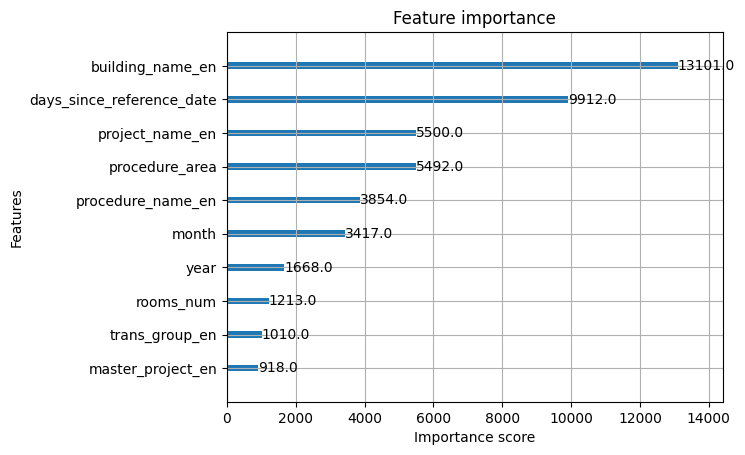

In [290]:
from sklearn.metrics import mean_absolute_error
# Predict
preds_log = model.predict(X_test)

# Convert back from Log to actual Price
preds_actual = np.exp(preds_log)
y_test_actual = np.exp(y_test)

# Calculate Mean Absolute Error (Average error in price)
mae = mean_absolute_error(y_test_actual, preds_actual)
print(f"Average Prediction Error: {mae:.2f}")

# Feature Importance: See what actually drives the price
xgb.plot_importance(model, max_num_features=10)

In [291]:
from sklearn.metrics import median_absolute_error
med_ae = median_absolute_error(y_test_actual, preds_actual)
print(f"Median Error: {med_ae}")

Median Error: 131711.31250000017


In [292]:
prices = np.expm1(y)
prices

0          809,455.00000
1        1,400,000.00000
2          874,000.00000
3        1,500,000.00000
4        1,187,500.00000
               ...      
807100   1,164,000.00000
807101   1,288,960.00000
807102   3,519,000.00000
807084     860,000.00000
807532     510,000.00000
Name: actual_worth_log, Length: 807533, dtype: float64

In [293]:
median_price = prices.median()
print("Median price:", median_price)

Median price: 1065888.000000001


In [294]:
relative_error = (med_ae / median_price) * 100
print(f"Relative error: {relative_error:.2f}%")

Relative error: 12.36%
